# Assignment — Linear Regression on `penguins.csv`

**Question:** given a penguin's measurements, how heavy is it?

Target: `body_mass_g` &nbsp;·&nbsp; File: `penguins.csv`

Use only the numeric columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`.

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('../Data/penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## 1. Look at the data

> **Flow:** Shape, columns, missing values.

Run `.info()`. Which columns have missing values, and how many?

In [67]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

---
## 2. Clean

> **Flow:** Keep the four numeric columns, drop the rows with blanks.

We cannot fill in `body_mass_g` — that is the answer we are trying to predict.
Rows missing it have to go.

Keep `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`,
then `dropna()`.

In [68]:
df = df.drop(columns = ['species', 'island', 'sex'])
df = df.dropna(subset = 'body_mass_g')
df.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


*How many rows are left?*

In [69]:
df.shape

(342, 4)

---
## 3. Features and target

In [70]:
x = df.drop(columns = 'body_mass_g')  # x is independent 
y = df['body_mass_g']  # y is dependent 

---
## 4. Split

> **Flow:** `test_size=0.2`, `random_state=42`.

In [71]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

---
## 5. One feature

> **Flow:** Start with `flipper_length_mm` alone.

Train `LinearRegression`. Print the coefficient, the intercept and the R².

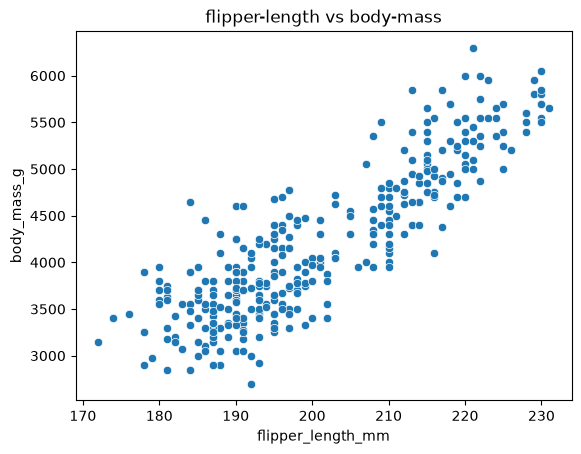

In [72]:
sns.scatterplot(data = df, x = 'flipper_length_mm', y = 'body_mass_g')
plt.title('flipper-length vs body-mass')
plt.show()


In [75]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train[['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']], y_train)

print("coef : ", model.coef_)
print("intercept : ", model.intercept_)

coef :  [48.67371868 10.92455958  4.00878846]
intercept :  -5946.037397381805


*Coefficient:* &nbsp;&nbsp; *R²:*

**Q.** The coefficient is about 48. Write one line explaining what that means in plain words —
what happens to the predicted weight if a penguin's flipper is 1 mm longer?

#### ANS : It means, for every 1mm of flipper length, penguins body will increase by 48.82gms

---
## 6. All three features

> **Flow:** Same model, two more columns.

Print the R².

In [77]:
r2 = model.score(
    x_test[['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']],
    y_test
)

print(r2)

0.7877806019338434


*R² with flipper only:* &nbsp;&nbsp; *R² with all three:*

**Q.** The score barely moved. That is not a mistake — it is the interesting part of this
assignment. Write two lines on why adding `bill_length_mm` and `bill_depth_mm` gave almost
nothing.

*Hint: what do all three columns really measure?*

#### ANS : All three features measure different aspects of a penguin’s overall body size. Flipper length already captures most of the size-related information needed to predict body mass, so adding bill length and bill depth provides very little additional information.

---
## 8. Metrics

> **Flow:** MAE, RMSE, R².

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = model.predict(x_test[["flipper_length_mm", "bill_depth_mm", "bill_length_mm"]])
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


*MAE:* &nbsp;&nbsp; *RMSE:* &nbsp;&nbsp; *R²:*

**Q.** The average penguin weighs about 4200 g. Is your MAE large or small compared to that?
One line.

#### ANS : The MAE (~310 g) is relatively small, representing less than 8% of the average penguin body mass (4200 g).


---
## 8. Coefficients

In [ ]:
# Print each feature name next to its coefficient
for feature, coef in zip(x.columns, model.coef_):
    print(f"{feature:20s}: {coef:.4f}")
print(f"{'Intercept':20s}: {model.intercept_:.4f}")


*Largest coefficient:*

**Q.** Does the largest coefficient mean that feature is the most important?
Careful — the three columns are measured on different scales. One line.

#### ANS : No, because the features are not standardized and have different units/scales, so raw coefficient magnitude alone does not imply feature importance.


---
## 9. Questions

**Q1.** Why can we not use `accuracy_score` on this problem?

**Q2.** We dropped rows where `body_mass_g` was missing instead of filling them with the
median. Why is filling in the target a bad idea?

**Q3.** In class, adding more features to the mpg model raised R² from 0.723 to 0.824.
Here it barely changed. In two lines — what is different about these two datasets?

#### ANS :
**Q1.** `accuracy_score` is strictly designed for classification with discrete class labels. Here `body_mass_g` is a continuous numerical target, requiring regression metrics like MAE, RMSE, and R².

**Q2.** Imputing missing values in the target column introduces artificial ground truth, biasing model training and distorting test evaluation metrics.

**Q3.** In the mpg dataset, features provide independent mechanical signals (weight, displacement, cylinders). In penguins, flipper length and bill dimensions are collinear indicators of overall body size, so flipper length already captures almost all available predictive information.
